# Trí tuệ Nhân tạo - Phân cụm Phân cấp (Hierarchical Clustering)
Thuật toán **Agglomerative Clustering** sử dụng phương pháp **Ward** để tối thiểu hóa phương sai nội cụm. Chúng ta sẽ xây dựng Dendrogram và phân nhóm 26 ngân hàng dựa trên 7 tiêu chí (đã chuẩn hóa Z-score) thành 3 mức độ rủi ro Tẩy xanh.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
# 1. Load dữ liệu
# Dữ liệu gốc dùng để đọc thông tin, gán nhãn cho dễ hiểu
df_orig = pd.read_excel('Combined_Features_Cleaned.xlsx')

# Gộp cột Bank_Name và Year thành 1 cột duy nhất (VD: Vietcombank_2023) để dễ theo dõi
if 'Year' in df_orig.columns:
    df_orig['Bank_Name'] = df_orig['Bank_Name'].astype(str) + '_' + df_orig['Year'].astype(str)

# Dữ liệu đã chuẩn hóa (Z-Score) dùng để đưa vào Model tính khoảng cách
df_scaled = pd.read_excel('Combined_Features_Scaled.xlsx')

# Trích xuất ma trận 7 tính năng đã Z-score
features = ['Report_Score_X', 'News_Score_Y_mean', 'Delta_Gap', 'E_tfidf', 'S_tfidf', 'G_tfidf', 'GSI_Raw']
X_scaled = df_scaled[features].values
bank_names = df_orig['Bank_Name'].values

### 1. Vẽ Biểu đồ phả hệ (Dendrogram)
Hình ảnh trực quan cho thấy sự kết hợp của các ngân hàng từ vi mô lên vĩ mô.

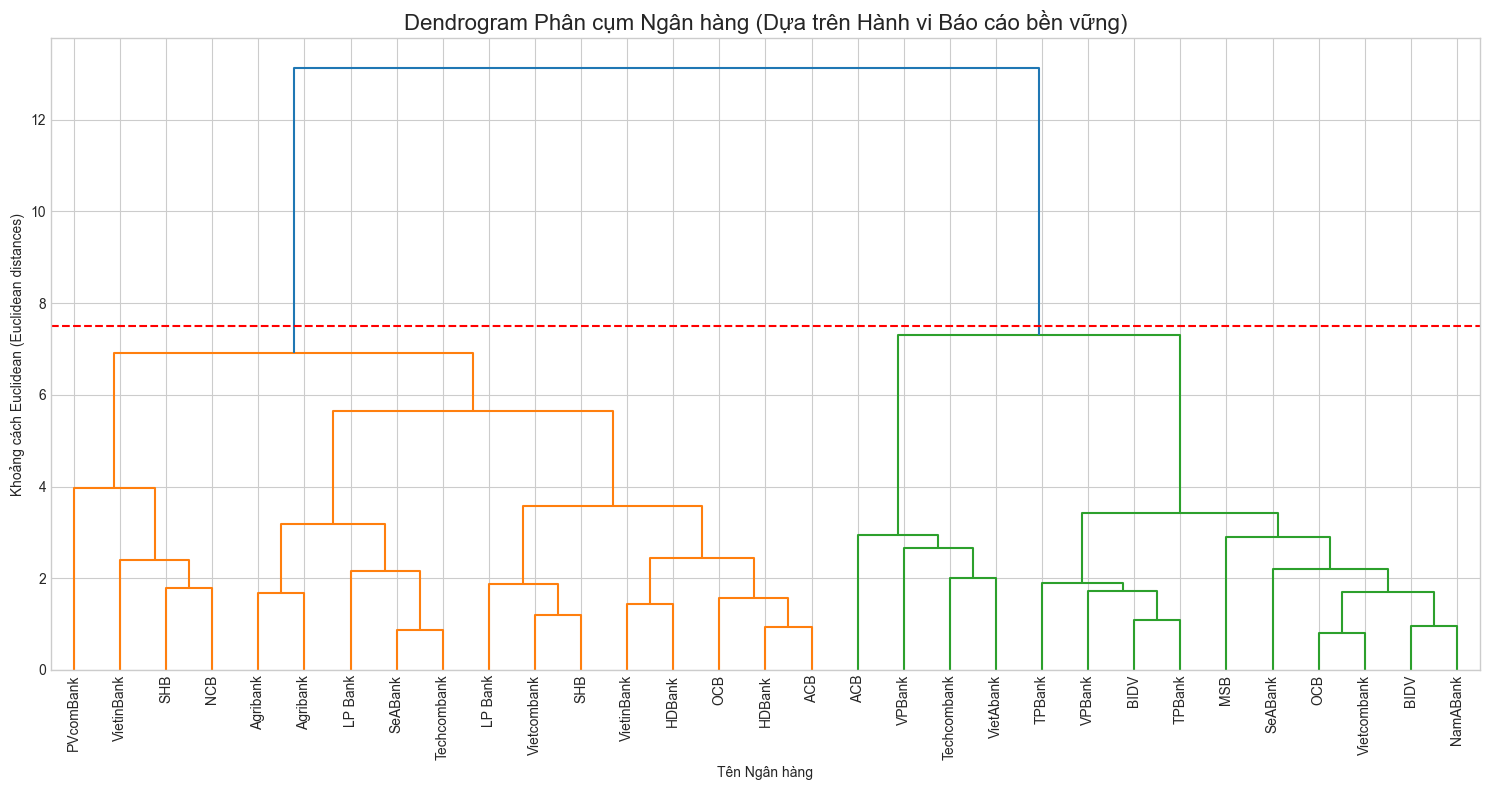

In [3]:
plt.figure(figsize=(15, 8))
plt.title("Dendrogram Phân cụm Ngân hàng (Dựa trên Hành vi Báo cáo bền vững)", fontsize=16)
plt.xlabel("Tên Ngân hàng")
plt.ylabel("Khoảng cách Euclidean (Euclidean distances)")

# Sử dụng phương pháp Linkage 'ward' để tối thiểu hóa phương sai khi gộp cụm
dendrogram = shc.dendrogram(shc.linkage(X_scaled, method='ward'), labels=bank_names, leaf_rotation=90, leaf_font_size=10)

# Vẽ 1 đường cắt ngang (Horizontal cut) để tạo ra 3 nhóm lớn nhất
plt.axhline(y=7.5, color='r', linestyle='--') # Mốc y cắt có thể tinh chỉnh tùy mắt
plt.tight_layout()
plt.show()

### 2. Thực thi Thuật toán (Thiết lập N=3) và Gắn nhãn nhận diện Tẩy xanh

In [4]:
# Khởi tạo mô hình
hc_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
clusters = hc_model.fit_predict(X_scaled)

# Gắn kết quả cụm (0, 1, 2) vào DataFrame gốc để phân tích Profiling
df_orig['Cluster'] = clusters

# Tính trung bình Delta_Gap (Độ lệch Phóng đại) của mỗi cụm
cluster_profile = df_orig.groupby('Cluster').agg({
    'Delta_Gap': 'mean',
    'Report_Score_X': 'mean',
    'GSI_Raw': 'mean',
    'Bank_Name': 'count'
}).rename(columns={'Bank_Name': 'Số lượng'})

print("== ĐẶC ĐIỂM CHUNG CỦA 3 CỤM GỐC ==")
display(cluster_profile)

# Lập logic tự động quy gán Rủi ro Tẩy xanh dựa trên độ lớn của Delta_Gap
sorted_clusters = cluster_profile.sort_values(by='Delta_Gap', ascending=False).index.tolist()

label_mapping = {
    sorted_clusters[0]: "🔴 Rủi ro Tẩy xanh Cao",       # Delta_Gap to nhất -> Nguy hiểm nhất
    sorted_clusters[1]: "🟡 Rủi ro Tẩy xanh Tiềm ẩn",  # Mức giữa
    sorted_clusters[2]: "🟢 Ít/Không có Rủi ro"         # Chân thực nhất
}

# Áp dụng mapping vào bảng
df_orig['Risk_Label'] = df_orig['Cluster'].map(label_mapping)

print("\n== DANH SÁCH CÁC NGÂN HÀNG THEO NHÓM RỦI RO ==")
display(df_orig[['Bank_Name', 'Delta_Gap', 'Risk_Label']].sort_values('Risk_Label', ascending=False))

== ĐẶC ĐIỂM CHUNG CỦA 3 CỤM GỐC ==


,Delta_Gap,Report_Score_X,GSI_Raw,Số lượng
Cluster,,,,
0,0.005790,0.013232,0.008822,17
1,0.019841,0.024769,0.012352,10
2,0.020910,0.029873,0.018895,4



== DANH SÁCH CÁC NGÂN HÀNG THEO NHÓM RỦI RO ==


,Bank_Name,Delta_Gap,Risk_Label
13,Vietcombank,0.009251,🟢 Ít/Không có Rủi ro
19,HDBank,0.007550,🟢 Ít/Không có Rủi ro
16,ACB,0.006398,🟢 Ít/Không có Rủi ro
1,Agribank,0.001733,🟢 Ít/Không có Rủi ro
14,VietinBank,0.007495,🟢 Ít/Không có Rủi ro
20,LP Bank,0.008843,🟢 Ít/Không có Rủi ro
21,NCB,-0.005489,🟢 Ít/Không có Rủi ro
11,Techcombank,0.006172,🟢 Ít/Không có Rủi ro
10,SHB,0.001658,🟢 Ít/Không có Rủi ro
9,SeABank,0.005663,🟢 Ít/Không có Rủi ro


### 3. Trực quan hóa Mức độ Tẩy xanh trên Tọa độ 2D (Sử dụng PCA)
Vì dữ liệu ở dạng 7 chiều, ta dùng PCA (Component Analysis) để lật nó thành mặt phẳng 2D giúp quan sát dễ dàng ranh giới của 3 nhóm Tẩy xanh.

C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


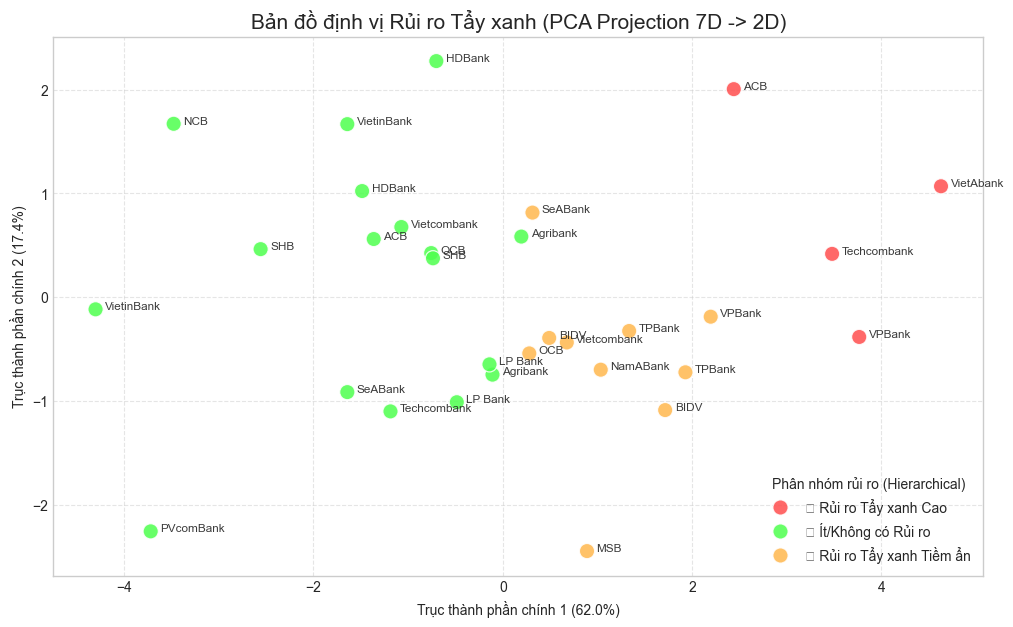

In [5]:
# PCA giảm số chiều dữ liệu từ 7 về lại 2 trục chính yếu
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_orig['PCA_1'] = X_pca[:, 0]
df_orig['PCA_2'] = X_pca[:, 1]

# Vẽ biểu đồ Scatter Color
plt.figure(figsize=(12, 7))
color_palette = {
    "🔴 Rủi ro Tẩy xanh Cao": "#ff4d4d",      # Đỏ
    "🟡 Rủi ro Tẩy xanh Tiềm ẩn": "#ffb84d",  # Vàng cam
    "🟢 Ít/Không có Rủi ro": "#4dff4d"         # Xanh lá
}

sns.scatterplot(x='PCA_1', y='PCA_2', hue='Risk_Label', palette=color_palette, 
                data=df_orig, s=120, edgecolor='white', alpha=0.85)

# Gắn nhãn tên Ngân hàng trực tiếp lên biểu đồ các chấm
for i in range(df_orig.shape[0]):
    plt.text(df_orig['PCA_1'].iloc[i] + 0.1, df_orig['PCA_2'].iloc[i], 
             df_orig['Bank_Name'].iloc[i], 
             fontsize=8.5, alpha=0.9)

plt.title('Bản đồ định vị Rủi ro Tẩy xanh (PCA Projection 7D -> 2D)', fontsize=15)
plt.xlabel(f'Trục thành phần chính 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Trục thành phần chính 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title="Phân nhóm rủi ro (Hierarchical)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 3.1. Phân tách biên giới các cụm rạch ròi (PCA kết hợp Convex Hull)
Để hội đồng thấy rõ 3 cụm được phân tách rạch ròi không bị "chồng lấn" (overlap) lên nhau, ta sử dụng thuật toán **Convex Hull (Đường bao lồi)** để vẽ các đa giác bao trọn từng lãnh thổ của mỗi nhóm rủi ro ngay trên mặt phẳng PCA 2D.

C:\Users\Admin\AppData\Local\Temp\ipykernel_12048\1341111589.py:42: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_12048\1341111589.py:42: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_12048\1341111589.py:42: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_12048\1341111589.py:43: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.savefig('PCA_ConvexHull_Boundaries.png', dpi=300, bbox_inches='tight')
C:\Users\Admin\AppData\Local\Temp\ipykernel_12048\1341111589.py:43: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.savefig('PCA_ConvexHull_Boundaries.png', dpi=300, bbox_inches='tight')
C:\Users\Admin\AppData\Local\Temp\ipykernel_12048\1

-> Đã in phân tách vùng ConvexHull và lưu tệp: PCA_ConvexHull_Boundaries.png


C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


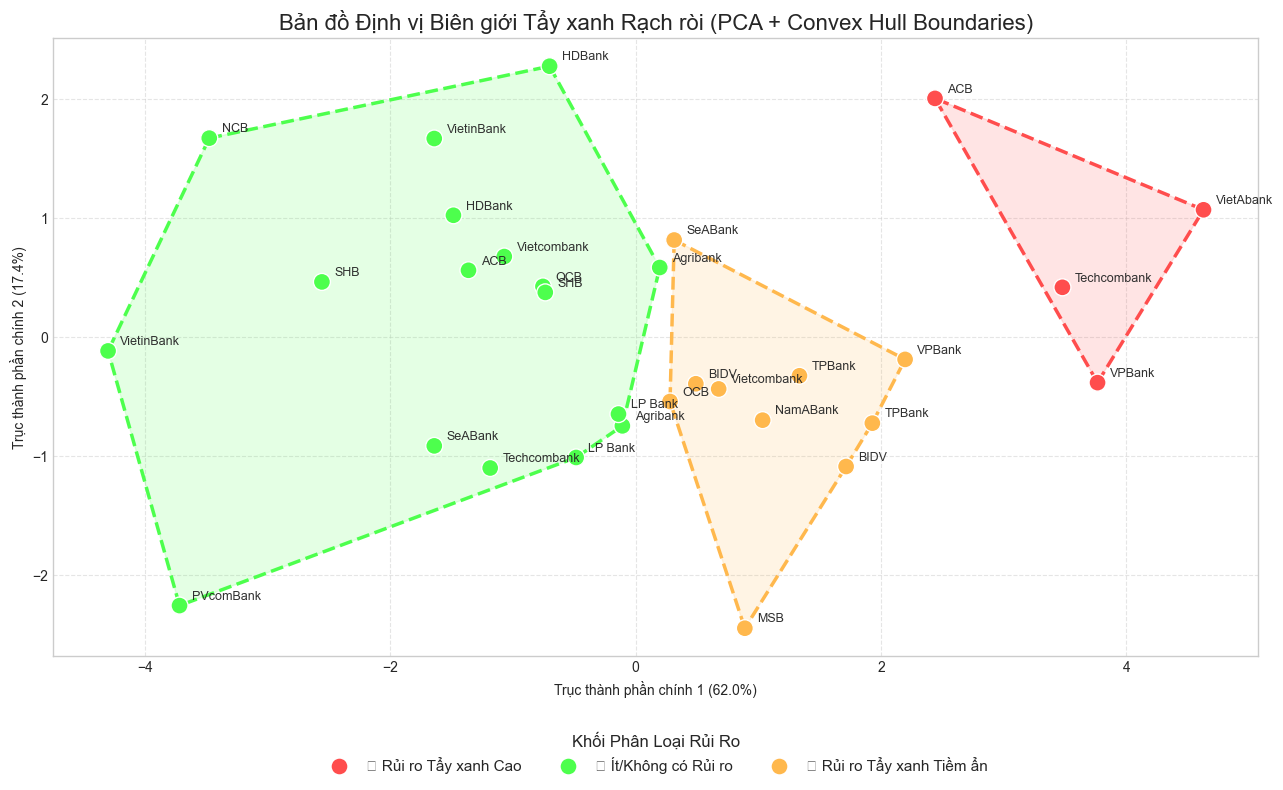

In [6]:
from scipy.spatial import ConvexHull

plt.figure(figsize=(13, 8))

# Vẽ móng của đường Scatter lên mặt phẳng
sns.scatterplot(x='PCA_1', y='PCA_2', hue='Risk_Label', palette=color_palette, 
                data=df_orig, s=150, edgecolor='white', alpha=1.0, zorder=5)

# Thuật toán chạy đa giác Convex Hull (Phân viền cụm rạch ròi)
for label in df_orig['Risk_Label'].unique():
    # Lấy tọa độ của tất cả các Ngân hàng thuộc Nhóm (Label) này
    points = df_orig[df_orig['Risk_Label'] == label][['PCA_1', 'PCA_2']].values
    
    # Một hình đa giác cần tối thiểu 3 điểm
    if len(points) >= 3: 
        hull = ConvexHull(points)
        
        # Đổ màu nhẹ xuống phần nền của hình đa giác (Vùng lãnh thổ)
        plt.fill(points[hull.vertices, 0], points[hull.vertices, 1], 
                 color=color_palette[label], alpha=0.15)
        
        # Vẽ viền đứt lốm đốm phân cách ranh giới quốc gia
        for simplex in hull.simplices:
            plt.plot(points[simplex, 0], points[simplex, 1], 
                     color=color_palette[label], linestyle='--', linewidth=2.5)

# Gắn nhãn tên lên đồ thị (Z-order cao để luôn nổi lên trên hình màu)
for i in range(df_orig.shape[0]):
    plt.text(df_orig['PCA_1'].iloc[i] + 0.1, df_orig['PCA_2'].iloc[i] + 0.05, 
             df_orig['Bank_Name'].iloc[i], 
             fontsize=9, alpha=0.95, zorder=6)

# Trình bày khoa học
plt.title('Bản đồ Định vị Biên giới Tẩy xanh Rạch ròi (PCA + Convex Hull Boundaries)', fontsize=16)
plt.xlabel(f'Trục thành phần chính 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Trục thành phần chính 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle='--', alpha=0.5, zorder=0)

# Kéo thanh ghi chú (Legend) xuống hẳn dưới đồ thị để vùng ranh giới lớn nhất có thể quan sát
plt.legend(title="Khối Phân Loại Rủi Ro", loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.savefig('PCA_ConvexHull_Boundaries.png', dpi=300, bbox_inches='tight')
print("-> Đã in phân tách vùng ConvexHull và lưu tệp: PCA_ConvexHull_Boundaries.png")

plt.show()

### 3.1. Trực quan hóa Mức độ Tẩy xanh trên trục GSI_Raw và Delta_Gap
Bên cạnh PCA, đây là biểu đồ 2 chiều mang tính thực tế cao nhất: Trục X là Điểm ESG tổng thể (GSI_Raw) và Trục Y là Mức độ Phóng đại/Tẩy xanh (Delta_Gap). Góc nhìn này giúp nhận diện thẳng mặt các ngân hàng thao túng truyền thông nhưng thực chất điểm GSI lại thấp.

C:\Users\Admin\AppData\Local\Temp\ipykernel_12048\3519606579.py:27: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.savefig('Hierarchical_Scatter_Delta_vs_GSI.png', dpi=300, bbox_inches='tight')
C:\Users\Admin\AppData\Local\Temp\ipykernel_12048\3519606579.py:27: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.savefig('Hierarchical_Scatter_Delta_vs_GSI.png', dpi=300, bbox_inches='tight')
C:\Users\Admin\AppData\Local\Temp\ipykernel_12048\3519606579.py:27: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Arial.
  plt.savefig('Hierarchical_Scatter_Delta_vs_GSI.png', dpi=300, bbox_inches='tight')


-> Đã xuất ảnh biểu đồ thành công: Hierarchical_Scatter_Delta_vs_GSI.png


C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


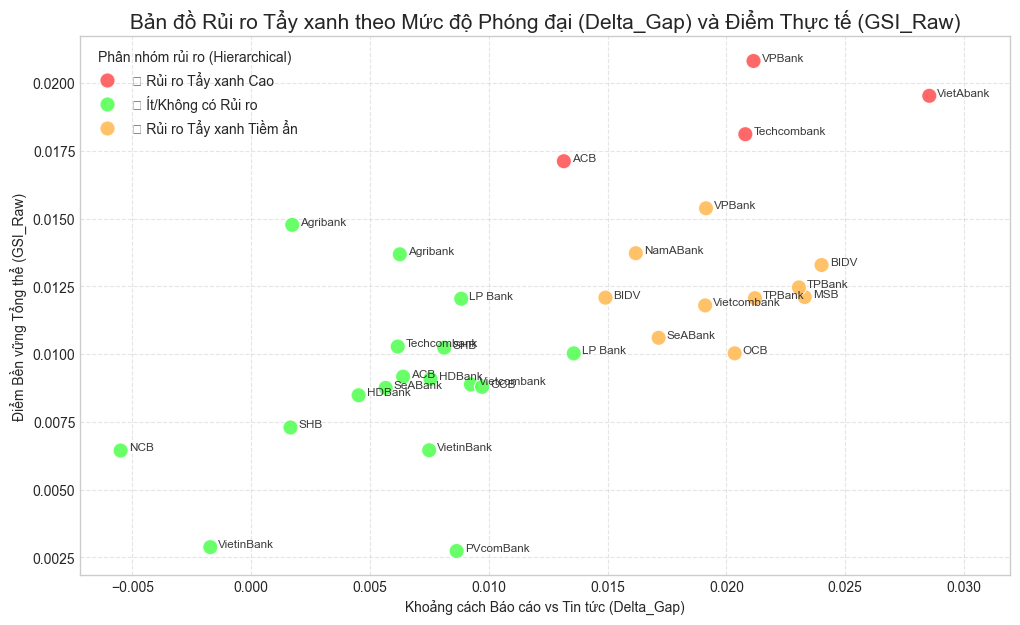

In [9]:
plt.figure(figsize=(12, 7))

# Sử dụng lại color_palette từ phần PCA ở trên
sns.scatterplot(x='Delta_Gap', y='GSI_Raw', hue='Risk_Label', palette=color_palette, 
                data=df_orig, s=120, edgecolor='white', alpha=0.85)

# Tính toán một lượng dời tên tương đối nhỏ trên trục X (hiện tại là Delta_Gap)
x_offset = (df_orig['Delta_Gap'].max() - df_orig['Delta_Gap'].min()) * 0.01

# Gắn nhãn tên Ngân hàng trực tiếp lên biểu đồ các chấm
for i in range(df_orig.shape[0]):
    plt.text(df_orig['Delta_Gap'].iloc[i] + x_offset,
             df_orig['GSI_Raw'].iloc[i],
             df_orig['Bank_Name'].iloc[i],
             fontsize=8.5, alpha=0.9)

plt.title('Bản đồ Rủi ro Tẩy xanh theo Mức độ Phóng đại (Delta_Gap) và Điểm Thực tế (GSI_Raw)', fontsize=15)
plt.xlabel('Khoảng cách Báo cáo vs Tin tức (Delta_Gap)')
plt.ylabel('Điểm Bền vững Tổng thể (GSI_Raw)')

plt.xlim(df_orig['Delta_Gap'].min() - x_offset*5, df_orig['Delta_Gap'].max() + x_offset*10)

plt.legend(title="Phân nhóm rủi ro (Hierarchical)")
plt.grid(True, linestyle='--', alpha=0.5)

# Tự động xuất lưu hình ảnh biểu đồ này ra file ảnh sắc nét (DPI=300)
plt.savefig('Hierarchical_Scatter_Delta_vs_GSI.png', dpi=300, bbox_inches='tight')
print("-> Đã xuất ảnh biểu đồ thành công: Hierarchical_Scatter_Delta_vs_GSI.png")

plt.show()

### 4. Xuất kết quả cuối cùng ra file Excel
Lưu lại bảng danh sách phân cụm rủi ro để đưa vào báo cáo Khóa luận định tính.

In [10]:
output_results = 'Final_Hierarchical_Clustering_Results.xlsx'
df_orig.drop(columns=['Cluster', 'PCA_1', 'PCA_2']).to_excel(output_results, index=False)
print(f"-> Đã tiến hành xếp hạng và lưu kết quả Phân cụm Phân cấp ra file: {output_results}")

-> Đã tiến hành xếp hạng và lưu kết quả Phân cụm Phân cấp ra file: Final_Hierarchical_Clustering_Results.xlsx
